             PERBANDINGAN 5 METODE OUTLIER PADA DATA CH4
Total Data Valid CH4: 20

>>> Metode: Isolation Forest (Jumlah Outlier: 1)
    - Minggu, 7 Juni 2026 | Nilai CH4: 1821.6421

>>> Metode: KNN (Jumlah Outlier: 1)
    - Minggu, 7 Juni 2026 | Nilai CH4: 1821.6421

>>> Metode: LOF (Jumlah Outlier: 1)
    - Jumat, 29 Agustus 2025 | Nilai CH4: 1871.7540

>>> Metode: COPOD (Jumlah Outlier: 1)
    - Minggu, 7 Juni 2026 | Nilai CH4: 1821.6421

>>> Metode: ECOD (Jumlah Outlier: 0)
    - Tidak ada outlier terdeteksi.



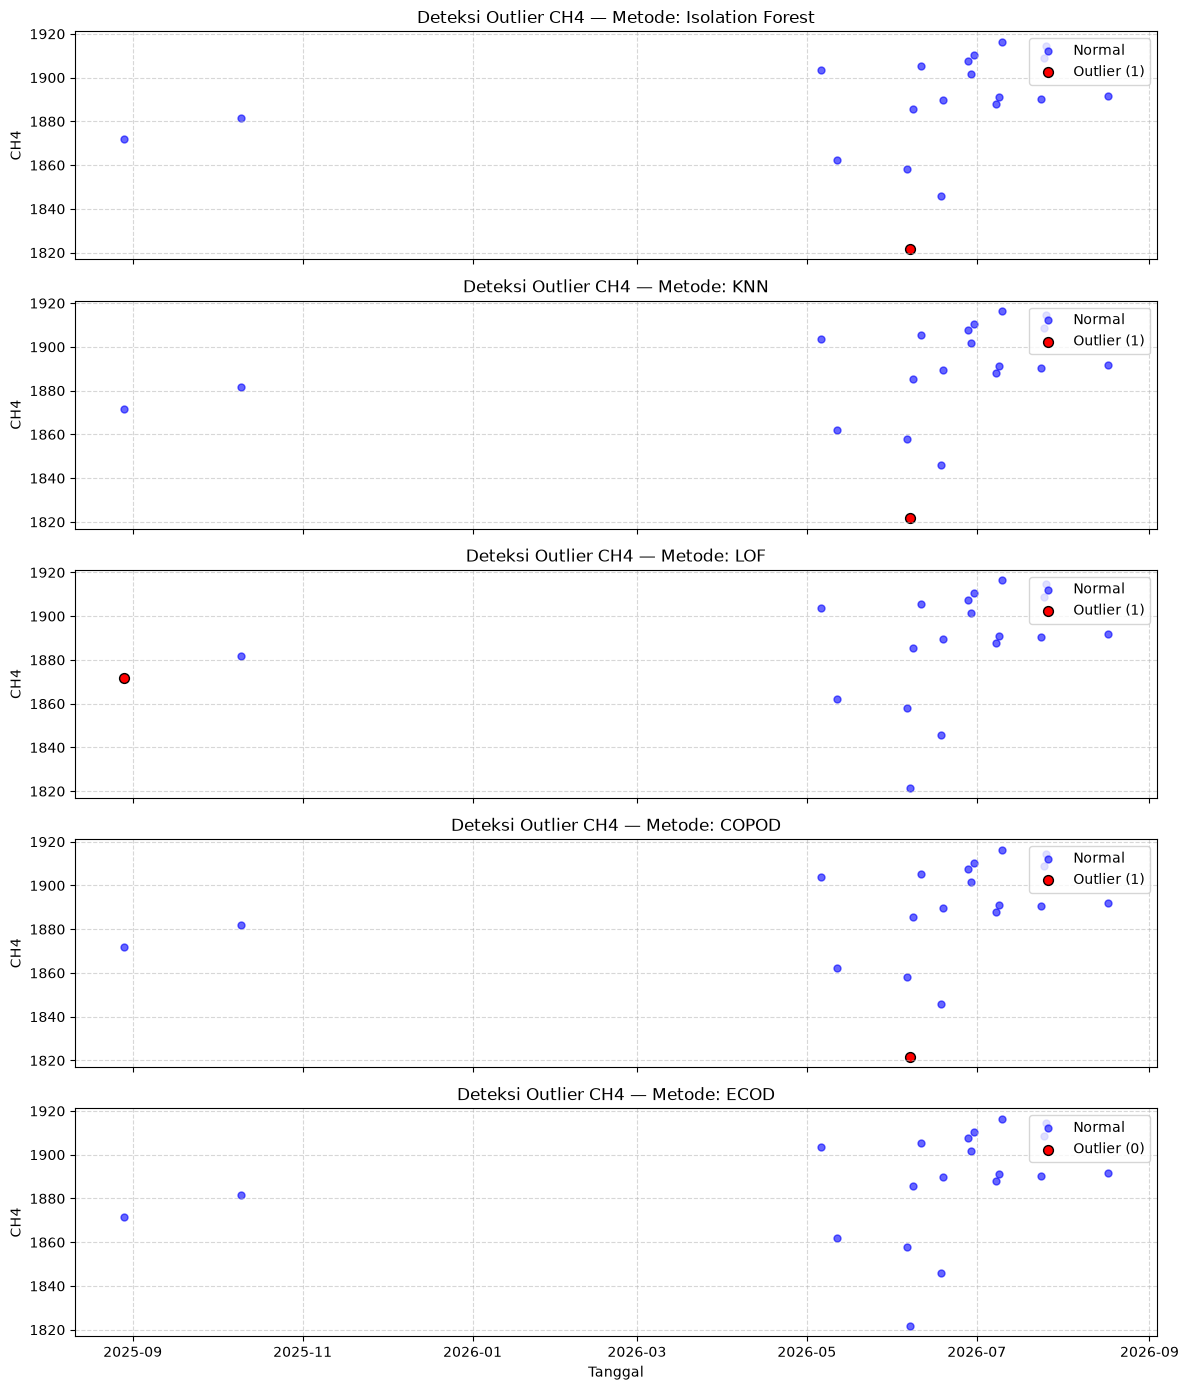

=== RINGKASAN JUMLAH OUTLIER CH4 PER METODE ===
- Isolation Forest: 1 outlier
- KNN: 1 outlier
- LOF: 1 outlier
- COPOD: 1 outlier
- ECOD: 0 outlier


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD

# 1. Load Data CH4
df = pd.read_csv("../data/csv/timeseries/CH4_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CH4']).copy()
df_clean['date_dt'] = pd.to_datetime(df_clean['date'])

# 2. Inisialisasi 5 Metode Outlier
contamination_rate = 0.05
models = {
    'Isolation Forest': IForest(contamination=contamination_rate, random_state=42),
    'KNN': KNN(contamination=contamination_rate),
    'LOF': LOF(contamination=contamination_rate),
    'COPOD': COPOD(contamination=contamination_rate),
    'ECOD': ECOD(contamination=contamination_rate)
}

X = df_clean[['CH4']].values
HARI_MAP = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
BULAN_MAP = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}

print("==========================================================================")
print("             PERBANDINGAN 5 METODE OUTLIER PADA DATA CH4")
print("==========================================================================")
print(f"Total Data Valid CH4: {len(df_clean)}\n")

summary_counts = {}
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (name, model) in enumerate(models.items()):
    model.fit(X)
    col_name = f'outlier_{name}'
    df_clean[col_name] = model.labels_ # 0 = Normal, 1 = Outlier
    
    normal = df_clean[df_clean[col_name] == 0]
    outliers = df_clean[df_clean[col_name] == 1]
    summary_counts[name] = len(outliers)
    
    print(f">>> Metode: {name} (Jumlah Outlier: {len(outliers)})")
    if len(outliers) > 0:
        for idx, row in outliers.iterrows():
            dt = row['date_dt']
            hari = HARI_MAP[dt.strftime('%A')]
            print(f"    - {hari}, {dt.day} {BULAN_MAP[dt.month]} {dt.year} | Nilai CH4: {row['CH4']:.4f}")
    else:
        print("    - Tidak ada outlier terdeteksi.")
    print()
    
    # Plot per metode
    ax = axes[i]
    ax.scatter(normal['date_dt'], normal['CH4'], color='blue', label='Normal', s=25, alpha=0.6)
    ax.scatter(outliers['date_dt'], outliers['CH4'], color='red', label=f'Outlier ({len(outliers)})', s=50, edgecolors='black')
    ax.set_title(f'Deteksi Outlier CH4 — Metode: {name}')
    ax.set_ylabel('CH4')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

print("=== RINGKASAN JUMLAH OUTLIER CH4 PER METODE ===")
for name, count in summary_counts.items():
    print(f"- {name}: {count} outlier")

             PERBANDINGAN 5 METODE OUTLIER PADA DATA CO
Total Data Valid CO: 192

>>> Metode: Isolation Forest (Jumlah Outlier: 10)
    - Minggu, 14 September 2025 | Nilai CO: 0.0174
    - Rabu, 24 September 2025 | Nilai CO: 0.0416
    - Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    - Minggu, 5 April 2026 | Nilai CO: 0.0176
    - Selasa, 5 Mei 2026 | Nilai CO: 0.0176
    - Selasa, 12 Mei 2026 | Nilai CO: 0.0170
    - Sabtu, 13 Juni 2026 | Nilai CO: 0.0187
    - Senin, 29 Juni 2026 | Nilai CO: 0.0214
    - Rabu, 15 Juli 2026 | Nilai CO: 0.0191
    - Senin, 10 Agustus 2026 | Nilai CO: 0.0384

>>> Metode: KNN (Jumlah Outlier: 10)
    - Minggu, 14 September 2025 | Nilai CO: 0.0174
    - Rabu, 24 September 2025 | Nilai CO: 0.0416
    - Rabu, 8 Oktober 2025 | Nilai CO: 0.0391
    - Kamis, 9 Oktober 2025 | Nilai CO: 0.0452
    - Selasa, 12 Mei 2026 | Nilai CO: 0.0170
    - Sabtu, 13 Juni 2026 | Nilai CO: 0.0187
    - Senin, 29 Juni 2026 | Nilai CO: 0.0214
    - Rabu, 15 Juli 2026 | Nilai CO: 0

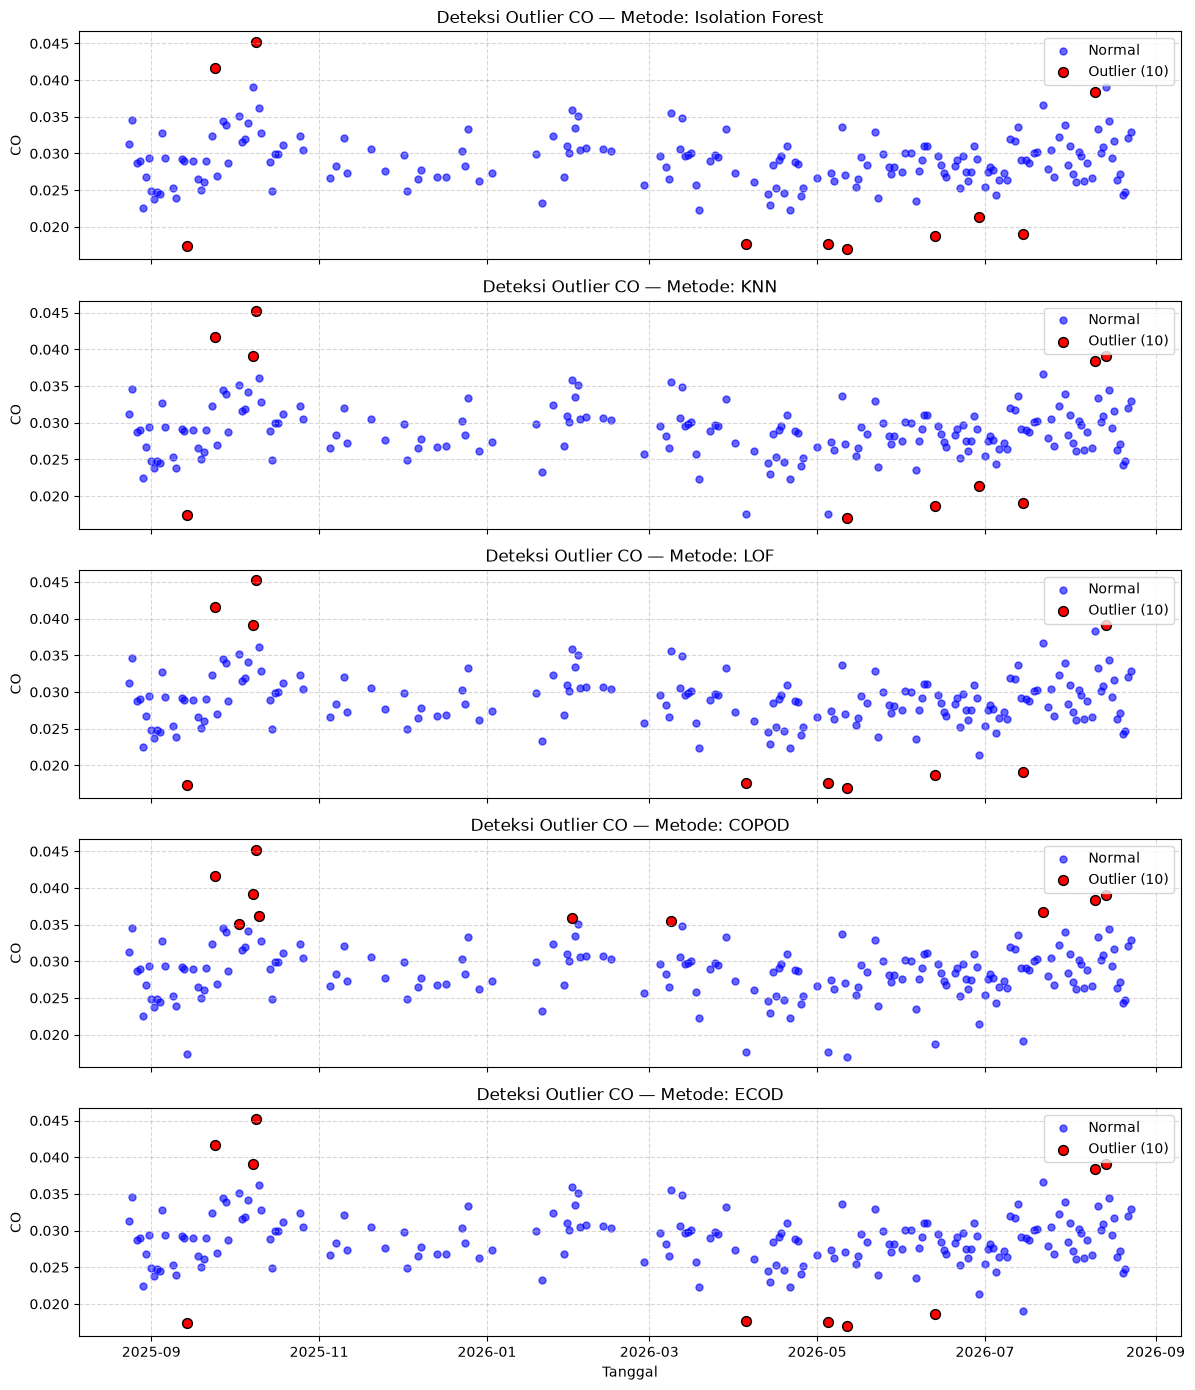

=== RINGKASAN JUMLAH OUTLIER CO PER METODE ===
- Isolation Forest: 10 outlier
- KNN: 10 outlier
- LOF: 10 outlier
- COPOD: 10 outlier
- ECOD: 10 outlier


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD

# 1. Load Data CO
df = pd.read_csv("../data/csv/timeseries/CO_gresik_timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()
df_clean['date_dt'] = pd.to_datetime(df_clean['date'])

# 2. Inisialisasi 5 Metode Outlier
contamination_rate = 0.05
models = {
    'Isolation Forest': IForest(contamination=contamination_rate, random_state=42),
    'KNN': KNN(contamination=contamination_rate),
    'LOF': LOF(contamination=contamination_rate),
    'COPOD': COPOD(contamination=contamination_rate),
    'ECOD': ECOD(contamination=contamination_rate)
}

X = df_clean[['CO']].values
HARI_MAP = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
BULAN_MAP = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}

print("==========================================================================")
print("             PERBANDINGAN 5 METODE OUTLIER PADA DATA CO")
print("==========================================================================")
print(f"Total Data Valid CO: {len(df_clean)}\n")

summary_counts = {}
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (name, model) in enumerate(models.items()):
    model.fit(X)
    col_name = f'outlier_{name}'
    df_clean[col_name] = model.labels_ # 0 = Normal, 1 = Outlier
    
    normal = df_clean[df_clean[col_name] == 0]
    outliers = df_clean[df_clean[col_name] == 1]
    summary_counts[name] = len(outliers)
    
    print(f">>> Metode: {name} (Jumlah Outlier: {len(outliers)})")
    if len(outliers) > 0:
        for idx, row in outliers.iterrows():
            dt = row['date_dt']
            hari = HARI_MAP[dt.strftime('%A')]
            print(f"    - {hari}, {dt.day} {BULAN_MAP[dt.month]} {dt.year} | Nilai CO: {row['CO']:.4f}")
    else:
        print("    - Tidak ada outlier terdeteksi.")
    print()
    
    # Plot per metode
    ax = axes[i]
    ax.scatter(normal['date_dt'], normal['CO'], color='blue', label='Normal', s=25, alpha=0.6)
    ax.scatter(outliers['date_dt'], outliers['CO'], color='red', label=f'Outlier ({len(outliers)})', s=50, edgecolors='black')
    ax.set_title(f'Deteksi Outlier CO — Metode: {name}')
    ax.set_ylabel('CO')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

print("=== RINGKASAN JUMLAH OUTLIER CO PER METODE ===")
for name, count in summary_counts.items():
    print(f"- {name}: {count} outlier")

             PERBANDINGAN 5 METODE OUTLIER PADA DATA NO2
Total Data Valid NO2: 200

>>> Metode: Isolation Forest (Jumlah Outlier: 10)
    - Rabu, 24 September 2025 | Nilai NO2: 0.0003
    - Minggu, 28 September 2025 | Nilai NO2: -0.0000
    - Kamis, 9 Oktober 2025 | Nilai NO2: 0.0001
    - Rabu, 17 Desember 2025 | Nilai NO2: 0.0000
    - Senin, 20 April 2026 | Nilai NO2: 0.0002
    - Jumat, 29 Mei 2026 | Nilai NO2: 0.0002
    - Selasa, 2 Juni 2026 | Nilai NO2: 0.0002
    - Senin, 8 Juni 2026 | Nilai NO2: 0.0002
    - Kamis, 18 Juni 2026 | Nilai NO2: 0.0001
    - Selasa, 30 Juni 2026 | Nilai NO2: 0.0001

>>> Metode: KNN (Jumlah Outlier: 10)
    - Senin, 25 Agustus 2025 | Nilai NO2: 0.0001
    - Rabu, 24 September 2025 | Nilai NO2: 0.0003
    - Kamis, 9 Oktober 2025 | Nilai NO2: 0.0001
    - Senin, 20 April 2026 | Nilai NO2: 0.0002
    - Jumat, 29 Mei 2026 | Nilai NO2: 0.0002
    - Selasa, 2 Juni 2026 | Nilai NO2: 0.0002
    - Senin, 8 Juni 2026 | Nilai NO2: 0.0002
    - Selasa, 9 Juni 2

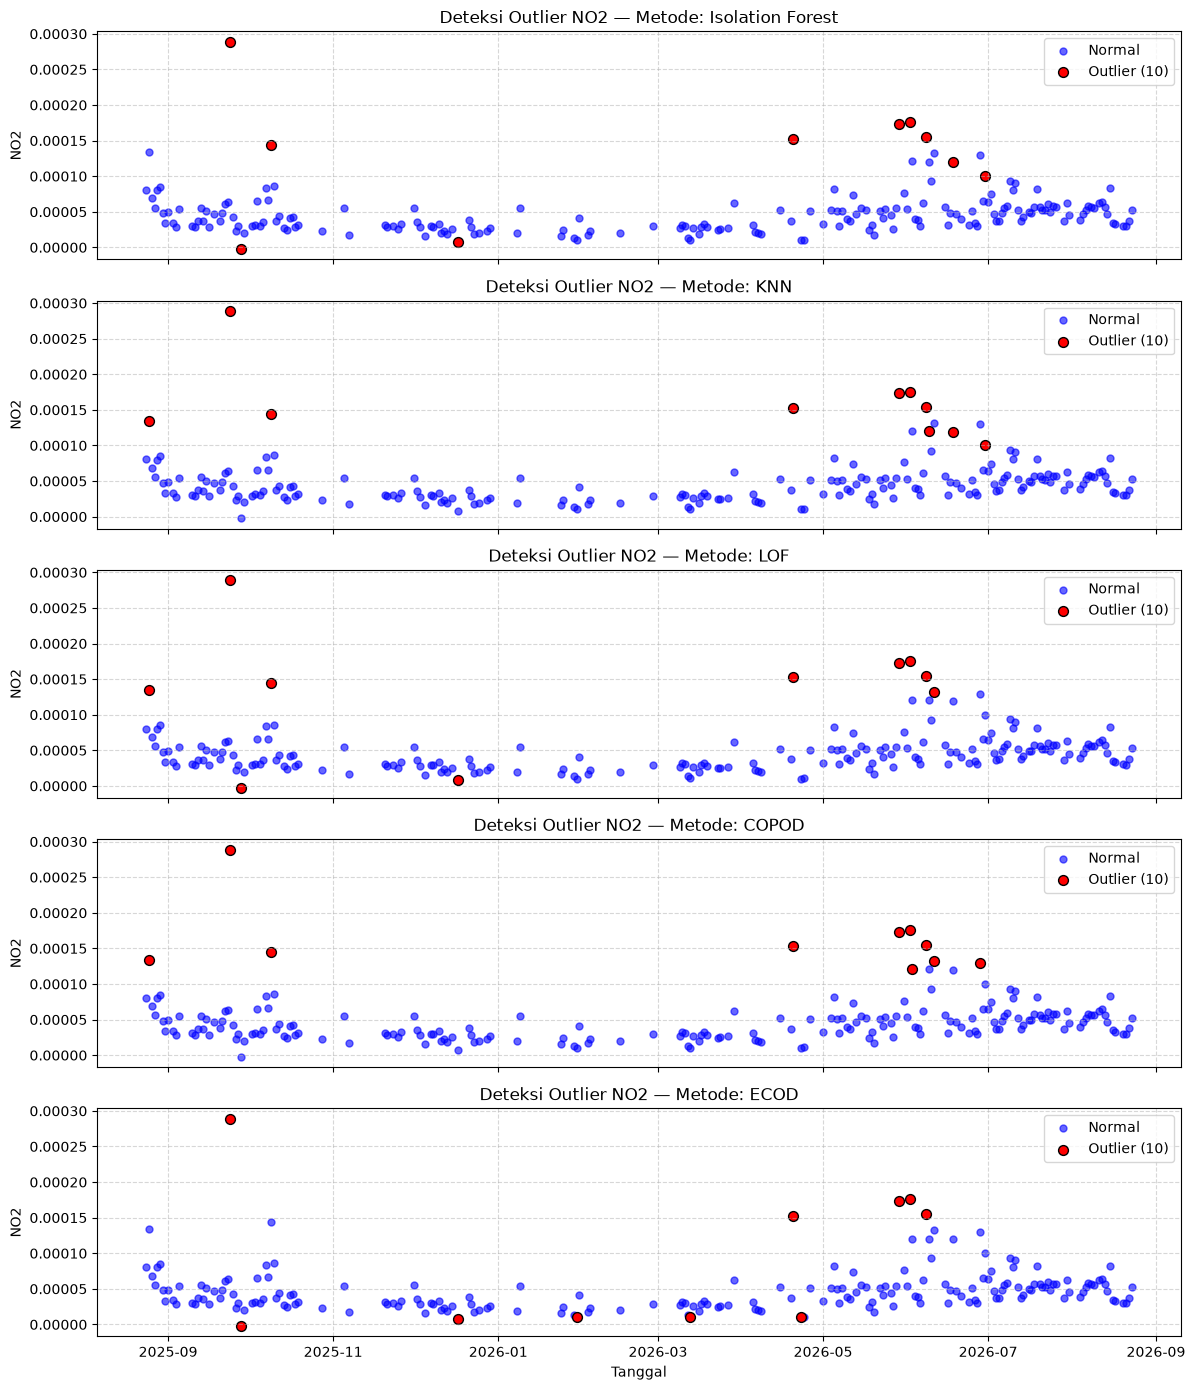

=== RINGKASAN JUMLAH OUTLIER NO2 PER METODE ===
- Isolation Forest: 10 outlier
- KNN: 10 outlier
- LOF: 10 outlier
- COPOD: 10 outlier
- ECOD: 10 outlier


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD

# 1. Load Data NO2
df = pd.read_csv("../data/csv/timeseries/NO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()
df_clean['date_dt'] = pd.to_datetime(df_clean['date'])

# 2. Inisialisasi 5 Metode Outlier
contamination_rate = 0.05
models = {
    'Isolation Forest': IForest(contamination=contamination_rate, random_state=42),
    'KNN': KNN(contamination=contamination_rate),
    'LOF': LOF(contamination=contamination_rate),
    'COPOD': COPOD(contamination=contamination_rate),
    'ECOD': ECOD(contamination=contamination_rate)
}

X = df_clean[['NO2']].values
HARI_MAP = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
BULAN_MAP = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}

print("==========================================================================")
print("             PERBANDINGAN 5 METODE OUTLIER PADA DATA NO2")
print("==========================================================================")
print(f"Total Data Valid NO2: {len(df_clean)}\n")

summary_counts = {}
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (name, model) in enumerate(models.items()):
    model.fit(X)
    col_name = f'outlier_{name}'
    df_clean[col_name] = model.labels_ # 0 = Normal, 1 = Outlier
    
    normal = df_clean[df_clean[col_name] == 0]
    outliers = df_clean[df_clean[col_name] == 1]
    summary_counts[name] = len(outliers)
    
    print(f">>> Metode: {name} (Jumlah Outlier: {len(outliers)})")
    if len(outliers) > 0:
        for idx, row in outliers.iterrows():
            dt = row['date_dt']
            hari = HARI_MAP[dt.strftime('%A')]
            print(f"    - {hari}, {dt.day} {BULAN_MAP[dt.month]} {dt.year} | Nilai NO2: {row['NO2']:.4f}")
    else:
        print("    - Tidak ada outlier terdeteksi.")
    print()
    
    # Plot per metode
    ax = axes[i]
    ax.scatter(normal['date_dt'], normal['NO2'], color='blue', label='Normal', s=25, alpha=0.6)
    ax.scatter(outliers['date_dt'], outliers['NO2'], color='red', label=f'Outlier ({len(outliers)})', s=50, edgecolors='black')
    ax.set_title(f'Deteksi Outlier NO2 — Metode: {name}')
    ax.set_ylabel('NO2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

print("=== RINGKASAN JUMLAH OUTLIER NO2 PER METODE ===")
for name, count in summary_counts.items():
    print(f"- {name}: {count} outlier")

             PERBANDINGAN 5 METODE OUTLIER PADA DATA SO2
Total Data Valid SO2: 235

>>> Metode: Isolation Forest (Jumlah Outlier: 12)
    - Selasa, 26 Agustus 2025 | Nilai SO2: 0.0014
    - Minggu, 31 Agustus 2025 | Nilai SO2: -0.0006
    - Senin, 1 September 2025 | Nilai SO2: -0.0004
    - Sabtu, 27 September 2025 | Nilai SO2: 0.0006
    - Sabtu, 18 Oktober 2025 | Nilai SO2: -0.0005
    - Selasa, 28 Oktober 2025 | Nilai SO2: -0.0005
    - Senin, 29 Desember 2025 | Nilai SO2: 0.0006
    - Jumat, 27 Maret 2026 | Nilai SO2: -0.0005
    - Rabu, 6 Mei 2026 | Nilai SO2: 0.0004
    - Rabu, 10 Juni 2026 | Nilai SO2: 0.0007
    - Jumat, 26 Juni 2026 | Nilai SO2: -0.0003
    - Kamis, 13 Agustus 2026 | Nilai SO2: -0.0007

>>> Metode: KNN (Jumlah Outlier: 12)
    - Selasa, 26 Agustus 2025 | Nilai SO2: 0.0014
    - Minggu, 31 Agustus 2025 | Nilai SO2: -0.0006
    - Senin, 1 September 2025 | Nilai SO2: -0.0004
    - Sabtu, 18 Oktober 2025 | Nilai SO2: -0.0005
    - Selasa, 28 Oktober 2025 | Nilai S

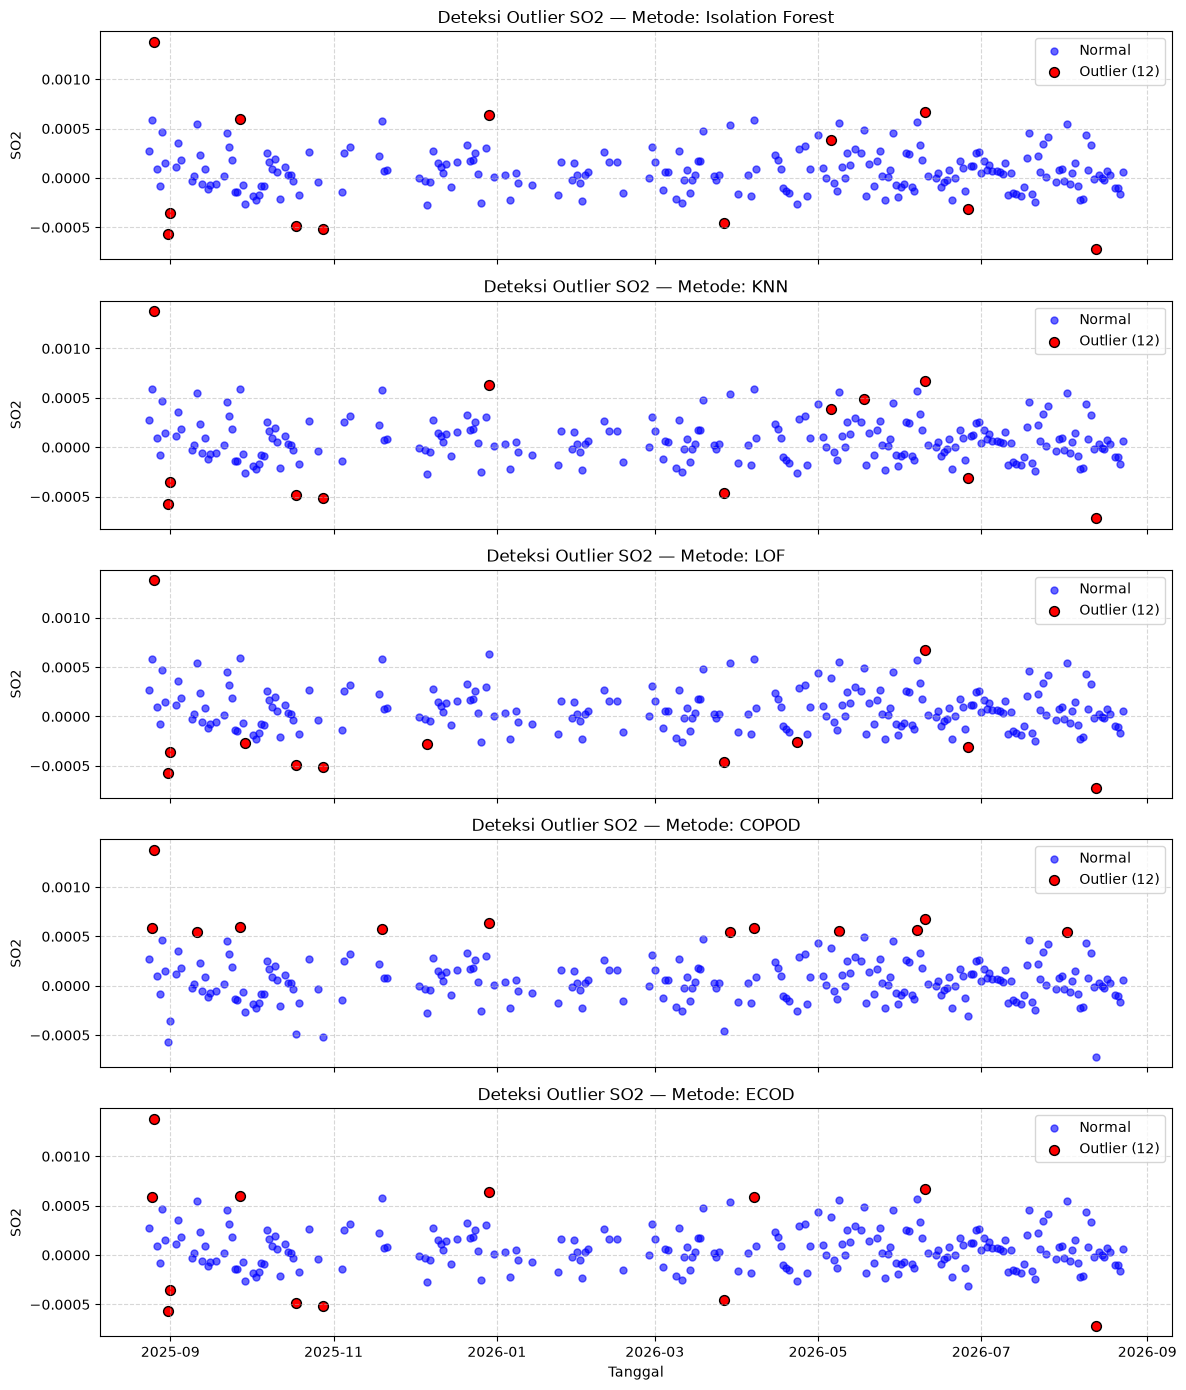

=== RINGKASAN JUMLAH OUTLIER SO2 PER METODE ===
- Isolation Forest: 12 outlier
- KNN: 12 outlier
- LOF: 12 outlier
- COPOD: 12 outlier
- ECOD: 12 outlier


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD

# 1. Load Data SO2
df = pd.read_csv("../data/csv/timeseries/SO2_gresik_timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()
df_clean['date_dt'] = pd.to_datetime(df_clean['date'])

# 2. Inisialisasi 5 Metode Outlier
contamination_rate = 0.05
models = {
    'Isolation Forest': IForest(contamination=contamination_rate, random_state=42),
    'KNN': KNN(contamination=contamination_rate),
    'LOF': LOF(contamination=contamination_rate),
    'COPOD': COPOD(contamination=contamination_rate),
    'ECOD': ECOD(contamination=contamination_rate)
}

X = df_clean[['SO2']].values
HARI_MAP = {'Monday': 'Senin', 'Tuesday': 'Selasa', 'Wednesday': 'Rabu', 'Thursday': 'Kamis', 'Friday': 'Jumat', 'Saturday': 'Sabtu', 'Sunday': 'Minggu'}
BULAN_MAP = {1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'}

print("==========================================================================")
print("             PERBANDINGAN 5 METODE OUTLIER PADA DATA SO2")
print("==========================================================================")
print(f"Total Data Valid SO2: {len(df_clean)}\n")

summary_counts = {}
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (name, model) in enumerate(models.items()):
    model.fit(X)
    col_name = f'outlier_{name}'
    df_clean[col_name] = model.labels_ # 0 = Normal, 1 = Outlier
    
    normal = df_clean[df_clean[col_name] == 0]
    outliers = df_clean[df_clean[col_name] == 1]
    summary_counts[name] = len(outliers)
    
    print(f">>> Metode: {name} (Jumlah Outlier: {len(outliers)})")
    if len(outliers) > 0:
        for idx, row in outliers.iterrows():
            dt = row['date_dt']
            hari = HARI_MAP[dt.strftime('%A')]
            print(f"    - {hari}, {dt.day} {BULAN_MAP[dt.month]} {dt.year} | Nilai SO2: {row['SO2']:.4f}")
    else:
        print("    - Tidak ada outlier terdeteksi.")
    print()
    
    # Plot per metode
    ax = axes[i]
    ax.scatter(normal['date_dt'], normal['SO2'], color='blue', label='Normal', s=25, alpha=0.6)
    ax.scatter(outliers['date_dt'], outliers['SO2'], color='red', label=f'Outlier ({len(outliers)})', s=50, edgecolors='black')
    ax.set_title(f'Deteksi Outlier SO2 — Metode: {name}')
    ax.set_ylabel('SO2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

print("=== RINGKASAN JUMLAH OUTLIER SO2 PER METODE ===")
for name, count in summary_counts.items():
    print(f"- {name}: {count} outlier")